# Experimento 3 — Veredicto por contenido (conectores conclusivos)

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento2.ipynb`. La sección 1 repite de forma resumida la configuración común (misma
semilla, mismo split y mismos folds), de modo que los resultados son comparables con los experimentos anteriores.
Los experimentos 1 y 2 **no se vuelven a ejecutar**: sus métricas se registran como valores fijos tomados de sus
notebooks.

**Contenido**
1. Configuración común (resumen)
2. Experimento 3 — Veredicto por contenido

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta) y CV estratificada de 5 folds sobre el
80 %. Se decide con accuracy (métrica de Kaggle) y se reporta F1 macro como control.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas del experimento 2 tomadas de experimento2.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E2 = {
    "experimento": 2,
    "descripcion": "TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9999,
    "acc_cv": 0.8865,
    "std_cv": 0.0099,
    "f1_cv": 0.8908,
    "acc_test": 0.8992,
    "f1_test": 0.9031,
    "envio": "submission_02.csv",
    "kaggle_publico": None,
}
resultados.append(REFERENCIA_E2)

# Prueba de robustez sobre el test (sección 2.9 de experimento2.ipynb)
ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 1 (bolsa de palabras)", "escenario": "Original", "accuracy": 0.7238, "acc negativo vs positivo": 0.6071},
    {"modelo": "Exp. 1 (bolsa de palabras)", "escenario": "Oraciones desordenadas", "accuracy": 0.7208, "acc negativo vs positivo": 0.6030},
    {"modelo": "Exp. 1 (bolsa de palabras)", "escenario": "Última oración al inicio", "accuracy": 0.7242, "acc negativo vs positivo": 0.6071},
    {"modelo": "Exp. 2 (final de la reseña)", "escenario": "Original", "accuracy": 0.8992, "acc negativo vs positivo": 0.8588},
    {"modelo": "Exp. 2 (final de la reseña)", "escenario": "Oraciones desordenadas", "accuracy": 0.6858, "acc negativo vs positivo": 0.5567},
    {"modelo": "Exp. 2 (final de la reseña)", "escenario": "Última oración al inicio", "accuracy": 0.5742, "acc negativo vs positivo": 0.3964},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,None
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,None


## 2. Experimento 3 — Veredicto por contenido

**Motivación:** el experimento 2 subió la accuracy de CV de 0,736 a 0,887 separando el final de la reseña (última
oración y fragmento tras el último conector). La prueba de robustez de `experimento2.ipynb` mostró el costo: si el
veredicto no está al final, el modelo cae por debajo de la línea base (0,686 con las oraciones desordenadas y 0,574
con la última oración al inicio), porque aprendió una regla de **posición**.

**Objetivo:** identificar el veredicto por su **contenido** en lugar de su posición, para obtener un modelo que no
dependa del orden de las oraciones, y medir cuánta accuracy se puede conservar así.

**Proceso:**
1. Identificar cómo empiezan las oraciones y definir conectores **conclusivos** (introducen el veredicto) y
   **concesivos** (introducen una opinión secundaria).
2. Diagnóstico: comprobar con los datos qué marca el veredicto por contenido.
3. Comparar candidatos con CV en dos condiciones: folds de validación originales y con las oraciones desordenadas.
4. Elegir el candidato más preciso entre los robustos, ajustar `C`, evaluar en test (incluida la prueba de
   robustez) y enviar.

### 2.1 ¿Cómo empiezan las oraciones?

Se cuentan las dos primeras palabras de cada oración (sin contar la primera de cada reseña, que suele ser relleno sobre
la compra) para encontrar los conectores que usan las reseñas.

In [6]:
from collections import Counter

from joblib import Parallel, delayed

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")


def dividir_oraciones(texto):
    """Lista de oraciones de un texto normalizado."""
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


inicios = Counter()
for texto in X_train:
    for oracion in dividir_oraciones(texto)[1:]:
        palabras = re.sub(r"[,.;]", "", oracion).split()
        if len(palabras) > 3:
            inicios[" ".join(palabras[:2])] += 1

pd.DataFrame(inicios.most_common(30), columns=["inicio de oración", "frecuencia"]).T

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
inicio de oración,lo uso,eso si,la verdad,aun asi,por otro,la uso,lo tengo,por cierto,el envio,de paso,...,con todo,todavia no,lo compre,se carga,nada mas,la pantalla,lo deje,a fin,el manual,en la
frecuencia,1257,1195,946,594,572,561,524,492,458,455,...,295,290,268,264,189,180,179,177,160,160


Además de inicios descriptivos (`lo uso`, `el envio`, `la caja`), aparecen conectores que organizan la opinión.
Se agrupan en dos tipos:

| Tipo | Conectores | Papel esperado |
|---|---|---|
| **Conclusivo** | `aun asi`, `al final`, `con todo`, `a fin de cuentas`, `sin embargo`, `pero`, `en fin`, `igual`, `ahora`, `no obstante`, `de todas formas`, ... | introducen el veredicto final |
| **Concesivo** | `para ser honesto`, `he de decir`, `la verdad`, `por cierto`, `de paso`, `por otro lado`, `ademas`, `eso si`, ... | introducen una opinión secundaria o un comentario al margen |

In [7]:
CONCLUSIVOS = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|total|"
    r"en resumen|en definitiva|no obstante|de todas formas|aun con eso)\b"
)
CONCESIVOS = (
    r"^(y )?(para ser (honesto|honesta|sincero|sincera)|he de decir|la verdad|por cierto|de paso|"
    r"por otro lado|ademas|eso si|cabe decir|hay que decir|debo decir|si soy sincero)\b"
)


def tipo_oracion(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "conclusivo"
    if re.match(CONCESIVOS, oracion):
        return "concesivo"
    return "sin conector"


mascara_np = (y_train != "neutral").to_numpy()
tipos = X_train[mascara_np].map(lambda t: {tipo_oracion(o) for o in dividir_oraciones(t)})
print(f"Reseñas negativo/positivo con al menos una oración conclusiva: {tipos.map(lambda s: 'conclusivo' in s).mean():.1%}")
print(f"Reseñas negativo/positivo con al menos una oración concesiva: {tipos.map(lambda s: 'concesivo' in s).mean():.1%}")

Reseñas negativo/positivo con al menos una oración conclusiva: 31.1%
Reseñas negativo/positivo con al menos una oración concesiva: 48.9%


### 2.2 Diagnóstico: ¿el contenido marca el veredicto?

Para cada conector se mide:
- **% en la última oración:** dónde aparece habitualmente.
- **Coincidencia con la etiqueta:** si la opinión de las oraciones que empiezan con ese conector tiene el mismo signo
  que la etiqueta de la reseña (solo reseñas `negativo`/`positivo`).

Para estimar la polaridad de cada oración se entrena un clasificador auxiliar con las **últimas oraciones** de
`X_train` (que concentran el veredicto, experimento 2). Como ese clasificador ya vio las últimas oraciones, su
coincidencia ahí estaría inflada; por eso la coincidencia se mide **solo en oraciones que no son la última**, que el
clasificador no vio. Se consideran solo oraciones con una opinión clara (|puntaje| > 1,5).

In [8]:
ultimas_np = X_train[mascara_np].map(lambda t: dividir_oraciones(t)[-1])
modelo_polaridad = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(C=3, max_iter=2000, random_state=SEED)),
]).fit(ultimas_np, y_train[mascara_np])
signo = 1 if modelo_polaridad.classes_[1] == "positivo" else -1

CONECTORES_DIAGNOSTICO = [
    "aun asi", "al final", "con todo", "a fin de cuentas", "sin embargo", "pero",
    "eso si", "la verdad", "por otro lado", "por cierto", "de paso", "ademas", "para ser", "he de decir",
]


def conector_inicial(oracion):
    for c in CONECTORES_DIAGNOSTICO:
        if re.match(rf"^(y )?{c}\b", oracion):
            return c
    return "(sin conector)"


registros = []
for texto, etiqueta in zip(X_train[mascara_np], y_train[mascara_np]):
    oraciones = dividir_oraciones(texto)
    for i, oracion in enumerate(oraciones):
        registros.append({"conector": conector_inicial(oracion), "es_ultima": i == len(oraciones) - 1,
                          "oracion": oracion, "signo_etiqueta": 1 if etiqueta == "positivo" else -1})
registros = pd.DataFrame(registros)
registros["polaridad"] = signo * modelo_polaridad.decision_function(registros["oracion"])

no_ultimas = registros[~registros["es_ultima"] & (registros["polaridad"].abs() > 1.5)].copy()
no_ultimas["coincide"] = np.sign(no_ultimas["polaridad"]) == no_ultimas["signo_etiqueta"]
diagnostico = pd.DataFrame({
    "n oraciones": registros.groupby("conector").size(),
    "% en la última oración": registros.groupby("conector")["es_ultima"].mean() * 100,
    "coincidencia con la etiqueta (no últimas)": no_ultimas.groupby("conector")["coincide"].mean() * 100,
    "n (no últimas, opinión clara)": no_ultimas.groupby("conector").size(),
}).round(1).sort_values("n oraciones", ascending=False)
diagnostico

,n oraciones,% en la última oración,coincidencia con la etiqueta (no últimas),"n (no últimas, opinión clara)"
conector,,,,
(sin conector),20859,17.1,33.5,3117
eso si,1162,67.3,45.8,201
la verdad,946,29.1,24.6,357
aun asi,594,95.6,100.0,12
por otro lado,478,24.7,30.1,146
al final,341,99.1,0.0,1
por cierto,320,38.8,18.2,88
de paso,316,29.4,23.5,119
con todo,295,99.3,100.0,1


**Lectura del diagnóstico**

- **Los conectores conclusivos marcan el cierre de la reseña:** `aun asi`, `al final`, `con todo`, `a fin de cuentas`,
  `pero` y `sin embargo` aparecen en la última oración entre el 93 % y el 99 % de las veces. Como el experimento 2
  mostró que la última oración concentra el veredicto, estas oraciones son el veredicto, y se pueden reconocer por
  cómo empiezan, sin mirar su posición. (Su coincidencia en oraciones no últimas se basa en muy pocos casos, n ≤ 12, y
  no es concluyente.)
- **Los conectores concesivos introducen la opinión contraria:** las oraciones que empiezan con `he de decir` (6,5 %),
  `para ser ...` (8,3 %), `por cierto` (18,2 %), `de paso` (23,5 %) o `la verdad` (24,6 %) casi nunca coinciden con la
  etiqueta. También es una pista de contenido, en sentido inverso.
- **`eso si` es ambiguo** (45,8 %): a veces introduce el veredicto y a veces un matiz, y aparece en la última oración el
  67 % de las veces.
- **Las oraciones con opinión sin conector en medio de la reseña** coinciden con la etiqueta solo el 33,5 % de las
  veces: suelen ser la opinión que luego se contradice.
- **Cobertura:** solo el 31,1 % de las reseñas `negativo`/`positivo` tiene una oración conclusiva. En el resto, el
  contenido no marca cuál opinión es el veredicto.

### 2.3 Candidatos y evaluación de robustez con CV

Cada candidato agrega al texto completo una o más partes con su propio TF-IDF (igual que en el experimento 2), pero
ahora las partes se definen por **contenido**:

| Parte | Contenido | ¿Depende de la posición? |
|---|---|---|
| `texto` | reseña completa | no |
| `conclusivo` | oraciones que empiezan con un conector conclusivo | no |
| `concesivo` | oraciones que empiezan con un conector concesivo | no |
| `concesivo_fuerte` | solo `para ser ...`, `he de decir`, `por cierto`, `de paso` | no |
| `interno` | cláusula tras un contraste **dentro** de una oración (`..., pero ...`) | no |
| `ultima`, `tras_conector` | partes del experimento 2 (referencia) | **sí** |

Cada candidato se evalúa con los mismos 5 folds en dos condiciones: validación **original** y validación con las
**oraciones desordenadas** (permutación con semilla fija). Solo se usa `X_train`; el test no participa. Se fija
`C = 10` (el valor elegido en los experimentos 1 y 2) para comparar los candidatos; el `C` del modelo final se ajusta
después con su propia CV.

Las configuraciones de los experimentos 1 y 2 se incluyen como **filas de referencia**: la robustez con CV no se
midió en sus notebooks (allí se midió sobre el test) y es necesaria para comparar en igualdad de condiciones.

In [9]:
PATRON_CONECTOR_E2 = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
CONTRASTE_INTERNO = r"\b(pero|aunque|sin embargo|aun asi|en cambio|al final|con todo)\b"
CONCESIVOS_FUERTES = r"^(y )?(para ser|he de decir|por cierto|de paso|cabe decir|debo decir)\b"


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR_E2, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def clausula_interna(oraciones):
    partes = []
    for oracion in oraciones:
        coincidencias = list(re.finditer(CONTRASTE_INTERNO, oracion))
        if coincidencias and coincidencias[-1].start() > 0:
            partes.append(oracion[coincidencias[-1].start():])
    return " ".join(partes)


def separar_partes(textos):
    """DataFrame con las partes de cada reseña, para vectorizarlas por separado."""
    filas = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        filas.append({
            "texto": texto,
            "conclusivo": " ".join(o for o in oraciones if tipo_oracion(o) == "conclusivo"),
            "concesivo": " ".join(o for o in oraciones if tipo_oracion(o) == "concesivo"),
            "concesivo_fuerte": " ".join(o for o in oraciones if re.match(CONCESIVOS_FUERTES, o)),
            "interno": clausula_interna(oraciones),
            "ultima": oraciones[-1],
            "tras_conector": tras_ultimo_conector(texto),
        })
    return pd.DataFrame(filas)


def pipeline_partes(columnas, C=10):
    """Pipeline: separar partes -> un TF-IDF por parte -> regresión logística."""
    return Pipeline([
        ("partes", FunctionTransformer(separar_partes)),
        ("tfidf", ColumnTransformer([
            (col, TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True), col) for col in columnas
        ])),
        ("clf", LogisticRegression(C=C, max_iter=3000, random_state=SEED)),
    ])


def desordenar_oraciones(textos, seed=SEED):
    """Permuta al azar las oraciones de cada reseña (reproducible con la semilla)."""
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    """Mueve la última oración al inicio de la reseña."""
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


separar_partes(X_train.head(3))[["conclusivo", "concesivo", "interno", "ultima"]]

,conclusivo,concesivo,interno,ultima
0,,"por cierto, trae garantia de un año.",,"por cierto, trae garantia de un año."
1,"con todo, el material se ve defectuoso la verdad.","la verdad, el material me reslto optimo la verdad.",,"con todo, el material se ve defectuoso la verdad."
2,,,,el epmaque no vale lo que cuesta.


In [10]:
def _evaluar_fold(pipeline, k, idx_tr, idx_va):
    modelo = clone(pipeline).fit(X_train.iloc[idx_tr], y_train.iloc[idx_tr])
    X_va, y_va = X_train.iloc[idx_va], y_train.iloc[idx_va]
    return (accuracy_score(y_va, modelo.predict(X_va)),
            accuracy_score(y_va, modelo.predict(desordenar_oraciones(X_va, seed=SEED + k))))


def cv_robustez(pipeline):
    """Accuracy de CV con la validación original y con la validación desordenada (mismos folds)."""
    r = Parallel(n_jobs=-1)(delayed(_evaluar_fold)(pipeline, k, tr, va)
                            for k, (tr, va) in enumerate(skf.split(X_train, y_train)))
    r = np.array(r)
    return r[:, 0].mean(), r[:, 0].std(), r[:, 1].mean()


CANDIDATOS = {
    "[ref. exp. 1] texto": ["texto"],
    "[ref. exp. 2] texto + última + tras conector": ["texto", "ultima", "tras_conector"],
    "texto + conclusivo": ["texto", "conclusivo"],
    "texto + conclusivo + concesivo": ["texto", "conclusivo", "concesivo"],
    "texto + conclusivo + concesivo fuerte": ["texto", "conclusivo", "concesivo_fuerte"],
    "texto + conclusivo + interno": ["texto", "conclusivo", "interno"],
    "texto + conclusivo + concesivo + interno": ["texto", "conclusivo", "concesivo", "interno"],
}

filas = []
for nombre, columnas in CANDIDATOS.items():
    acc, std, acc_des = cv_robustez(pipeline_partes(columnas))
    filas.append({"candidato": nombre, "acc_cv original": acc, "std": std,
                  "acc_cv desordenada": acc_des, "caída": acc - acc_des})

comparacion = pd.DataFrame(filas).round(4)
comparacion

,candidato,acc_cv original,std,acc_cv desordenada,caída
0,[ref. exp. 1] texto,0.7364,0.0128,0.7336,0.0027
1,[ref. exp. 2] texto + última + tras conector,0.8865,0.0099,0.6715,0.2150
2,texto + conclusivo,0.7978,0.0146,0.7920,0.0058
3,texto + conclusivo + concesivo,0.7895,0.0163,0.7883,0.0011
4,texto + conclusivo + concesivo fuerte,0.7938,0.0113,0.7905,0.0032
5,texto + conclusivo + interno,0.8009,0.0144,0.7990,0.0020
6,texto + conclusivo + concesivo + interno,0.7960,0.0149,0.7935,0.0025


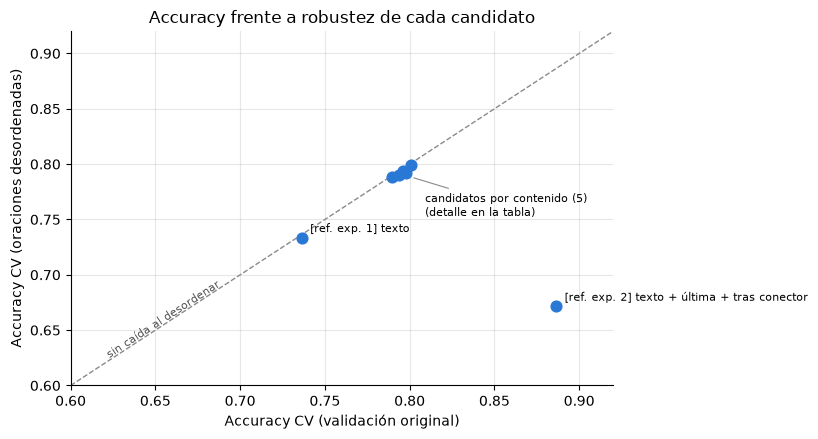

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(comparacion["acc_cv original"], comparacion["acc_cv desordenada"], s=60, color="#2a78d6", zorder=3)
referencias = comparacion[comparacion["candidato"].str.startswith("[ref")]
for _, fila in referencias.iterrows():
    ax.annotate(fila["candidato"], (fila["acc_cv original"], fila["acc_cv desordenada"]),
                xytext=(6, 4), textcoords="offset points", fontsize=8)
contenido = comparacion[~comparacion["candidato"].str.startswith("[ref")]
ax.annotate(f"candidatos por contenido ({len(contenido)})\n(detalle en la tabla)",
            (contenido["acc_cv original"].max(), contenido["acc_cv desordenada"].min()),
            xytext=(10, -28), textcoords="offset points", fontsize=8,
            arrowprops={"arrowstyle": "-", "color": "#8a8a8a", "linewidth": 0.8})
lim = (0.6, 0.92)
ax.plot(lim, lim, color="#8a8a8a", linestyle="--", linewidth=1)
ax.annotate("sin caída al desordenar", xy=(0.62, 0.625), fontsize=8, color="#555555", rotation=33)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("Accuracy CV (validación original)")
ax.set_ylabel("Accuracy CV (oraciones desordenadas)")
ax.set_title("Accuracy frente a robustez de cada candidato")
plt.show()

**Lectura de la comparación**

- **La configuración del experimento 2 es la más precisa (0,887) pero la menos robusta:** con la validación
  desordenada cae 21,5 puntos (a 0,672), por debajo de la línea base.
- **Todos los candidatos por contenido son robustos:** caen menos de 0,6 puntos al desordenar.
- **Mejoran unos 6 puntos sobre la línea base** (≈ 0,79–0,80 frente a 0,736), gracias a la parte `conclusivo`.
- **Agregar la parte `concesivo` no ayuda** (0,7895): incluye conectores ambiguos como `eso si` y `la verdad`. La
  versión con solo concesivos fuertes tampoco mejora.
- **`texto + conclusivo + interno`** obtiene la accuracy más alta entre los robustos (0,8009), pero solo 0,003 por
  encima de `texto + conclusivo` (0,7978), muy por debajo de la desviación entre folds (≈ 0,014). No es una diferencia
  real, así que se prefiere el candidato más simple.

### 2.4 ¿Por qué no se alcanza la accuracy del experimento 2 sin usar la posición?

Solo una parte de las reseñas tiene un conector conclusivo que marque el veredicto. En el resto, el veredicto es
simplemente **la última opinión**, sin ninguna marca de contenido. Por ejemplo:

- *"La batería es excelente. La cámara es pésima."* → `negativo`
- *"La cámara es pésima. La batería es excelente."* → `positivo`

Las dos reseñas tienen **exactamente las mismas palabras**; solo cambia el orden. Un modelo que no usa la posición
recibe la misma entrada en ambos casos y tiene que darles la misma predicción, así que falla en una de las dos. Es un
límite de **información**, no del modelo: en este conjunto de datos la recencia forma parte de la definición de la
etiqueta (el enunciado lo indica: el sentimiento depende del orden de las cláusulas, la recencia y los conectores).
Por eso existe un compromiso entre accuracy en estos datos y robustez ante cambios de orden.

### 2.5 Modelo del experimento 3

Se elige **texto completo + oraciones conclusivas**: entre los candidatos robustos (caída < 1 punto al desordenar),
su accuracy está empatada con la mejor dentro del ruido entre folds, y es el más simple. Se ajusta `C` con su
propia CV.

In [12]:
pipe_e3 = pipeline_partes(["texto", "conclusivo"])
grid_e3 = {"clf__C": [1, 3, 10, 30]}

busqueda_e3 = GridSearchCV(
    pipe_e3, grid_e3, cv=skf, scoring=SCORING, refit="accuracy",
    return_train_score=True, n_jobs=-1,
)
busqueda_e3.fit(X_train, y_train)

print("Mejor C:", busqueda_e3.best_params_["clf__C"])
print(f"Accuracy CV: {busqueda_e3.best_score_:.4f}")
print("Features:", len(busqueda_e3.best_estimator_.named_steps["tfidf"].get_feature_names_out()))

tabla_e3 = tabla_cv(busqueda_e3)
tabla_e3.insert(0, "C", tabla_e3.pop("params").map(lambda p: p["clf__C"]))
tabla_e3.sort_values("C")

Mejor C: 10
Accuracy CV: 0.7978
Features: 26057


,C,acc_train,acc_cv,std_cv,f1_cv,seg_ajuste
0,1,0.9458,0.7822,0.0142,0.7900,3.4502
1,3,0.9855,0.7942,0.0146,0.8024,3.8101
2,10,0.9980,0.7978,0.0146,0.8064,3.6321
3,30,0.9999,0.7971,0.0144,0.8058,2.3369


Test -> accuracy: 0.7963 | F1 macro: 0.8054

              precision    recall  f1-score   support

    negativo      0.717     0.708     0.712       843
     neutral      0.982     1.000     0.991       715
    positivo      0.714     0.711     0.713       842

    accuracy                          0.796      2400
   macro avg      0.804     0.807     0.805      2400
weighted avg      0.795     0.796     0.795      2400



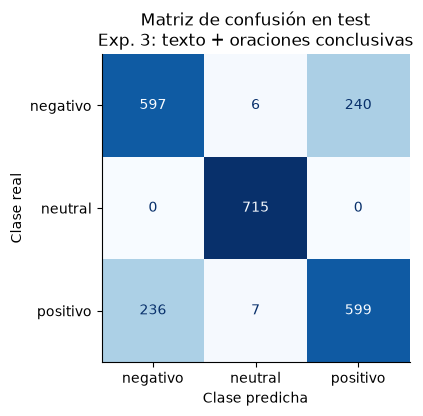

In [13]:
metricas_e3 = evaluar_en_test(busqueda_e3.best_estimator_, "Exp. 3: texto + oraciones conclusivas")

In [14]:
top_coeficientes(busqueda_e3.best_estimator_)

,negativo,neutral,positivo
0,conclusivo__mal (5.29),texto__trae (3.92),texto__supero todas (4.75)
1,texto__defraudo todas (4.80),texto__viene (3.70),texto__supero (4.75)
2,texto__defraudo (4.80),texto__la caja (3.20),texto__feliz (4.20)
3,conclusivo__endeble (4.65),texto__color (3.20),texto__verdad (3.78)
4,conclusivo__olvidable (4.21),texto__todavia (3.05),texto__me (3.68)
5,texto__resulto (4.03),texto__por ahora (2.99),conclusivo__eficiente (3.67)
6,texto__mal (4.00),texto__kilo (2.93),texto__sin pensarlo (3.66)
7,texto__decepciono (3.89),texto__unidades (2.90),conclusivo__espectacular (3.62)
8,texto__me decepciono (3.89),texto__viene en (2.87),texto__sobresaliente (3.59)
9,texto__harto (3.73),texto__pedi por (2.75),texto__me encanto (3.49)


### 2.6 Prueba de robustez en test

Los mismos dos escenarios de la sección 2.9 de `experimento2.ipynb`, aplicados al modelo del experimento 3. Los valores
de los experimentos 1 y 2 se toman de ese notebook (no se vuelven a ejecutar). El test solo se reporta.

In [15]:
np_test = (y_test != "neutral").to_numpy()
ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}

filas = []
for escenario, X_esc in ESCENARIOS.items():
    pred = busqueda_e3.best_estimator_.predict(X_esc)
    filas.append({"modelo": "Exp. 3 (veredicto por contenido)", "escenario": escenario,
                  "accuracy": accuracy_score(y_test, pred),
                  "acc negativo vs positivo": accuracy_score(y_test[np_test], pred[np_test])})

robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 1 (bolsa de palabras),Exp. 2 (final de la reseña),Exp. 3 (veredicto por contenido)
escenario,,,
Original,0.7238,0.8992,0.7962
Oraciones desordenadas,0.7208,0.6858,0.8004
Última oración al inicio,0.7242,0.5742,0.7996


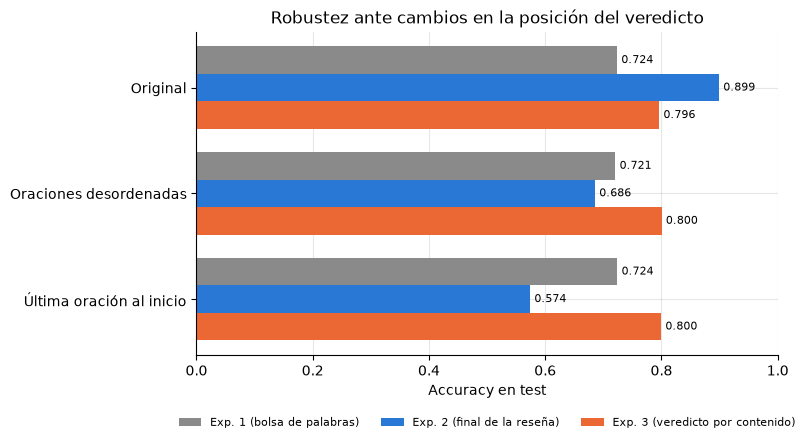

In [16]:
modelos = {
    "Exp. 1 (bolsa de palabras)": "#8a8a8a",
    "Exp. 2 (final de la reseña)": "#2a78d6",
    "Exp. 3 (veredicto por contenido)": "#eb6834",
}
escenarios = list(ESCENARIOS)
y_pos = np.arange(len(escenarios))
alto = 0.26

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for j, (nombre, color) in enumerate(modelos.items()):
    valores = robustez[robustez["modelo"] == nombre].set_index("escenario").loc[escenarios, "accuracy"]
    barras = ax.barh(y_pos + (j - 1) * alto, valores, height=alto, color=color, label=nombre)
    ax.bar_label(barras, fmt="%.3f", padding=3, fontsize=8)

ax.set_yticks(y_pos, escenarios)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy en test")
ax.set_title("Robustez ante cambios en la posición del veredicto")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False, fontsize=8)
plt.show()

### 2.7 Errores que quedan (sobre train, con predicciones de CV)

Como en el experimento 2, los errores se analizan con `cross_val_predict` sobre `X_train`, no sobre el test.

In [17]:
pred_cv_e3 = cross_val_predict(clone(busqueda_e3.best_estimator_), X_train, y_train, cv=skf, n_jobs=-1)

errores = (pred_cv_e3 != y_train.to_numpy()) & mascara_np
tiene_conclusivo = X_train.map(lambda t: any(tipo_oracion(o) == "conclusivo" for o in dividir_oraciones(t))).to_numpy()

print(f"Errores negativo/positivo en CV: {errores.sum()} de {mascara_np.sum()} ({errores.sum() / mascara_np.sum():.1%})")
for valor, nombre in [(True, "con oración conclusiva"), (False, "sin oración conclusiva")]:
    m = mascara_np & (tiene_conclusivo == valor)
    print(f"  Accuracy negativo vs positivo, reseñas {nombre}: "
          f"{(pred_cv_e3[m] == y_train.to_numpy()[m]).mean():.3f}  (n = {m.sum()})")

print()
muestra = X_train[errores].sample(4, random_state=SEED)
for idx, texto in muestra.items():
    pred = pred_cv_e3[X_train.index.get_loc(idx)]
    print(f"[real: {y_train[idx]}  ->  predicho: {pred}]")
    for oracion in dividir_oraciones(texto):
        print("    ", oracion)
    print()

Errores negativo/positivo en CV: 1936 de 6739 (28.7%)
  Accuracy negativo vs positivo, reseñas con oración conclusiva: 0.859  (n = 2099)
  Accuracy negativo vs positivo, reseñas sin oración conclusiva: 0.647  (n = 4640)

[real: positivo  ->  predicho: negativo]
     me llego el aparato el jueves por la tarde, dos dias despues de pedirlo.
     se carga por un puerto usb-c, por cierto el boton de encendido me parecio endeble segun lo que buscaba.
     lo estuve probando ese fin de semana en mi cuarto.
     en una ocasion tuve que escribirles por un par de cosas y la atencion al cliente me resulto de buena calidad con el tiempo.

[real: positivo  ->  predicho: negativo]
     lo compre hace mas o menos un mes y lo deje instalado en mi oficina, en el escritorio junto a la computadora.
     la verdad, no pare de tener problemas con la velocidad desde el primer dia.
     eso si, me encanto la ergonomia de principio a fin, la uso toda la jornada.
     todavia no me decido.

[real: positivo  ->

### 2.8 Registro y envío

In [18]:
registrar_resultado(
    experimento=3,
    descripcion="TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",
    busqueda=busqueda_e3,
    metricas_test=metricas_e3,
    envio="submission_03.csv",
)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,None
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,None
2,3,"TF-IDF (1,2) de texto completo + oraciones con conector conclusivo + LR (sin posición)",{'clf__C': 10},0.9980,0.7978,0.0146,0.8064,0.7963,0.8054,submission_03.csv,None


In [19]:
envio_e3 = generar_envio(busqueda_e3, numero=3)

Envío guardado en envios/submission_03.csv y modelo en modelos/modelo_03.joblib
Distribución de predicciones en eval (%):
answer
negativo    36.8
neutral     28.0
positivo    35.2


### 2.9 Análisis del experimento 3: alcances y límites

**Resultados:** accuracy de CV = **0,7978 ± 0,0146** (`C = 10`) y accuracy en test = **0,7963** (F1 macro 0,805).

| | Exp. 1 | Exp. 2 | Exp. 3 |
|---|---|---|---|
| Accuracy CV | 0,736 | **0,887** | 0,798 |
| Accuracy test (original) | 0,724 | **0,899** | 0,796 |
| Test, oraciones desordenadas | 0,721 | 0,686 | **0,800** |
| Test, última oración al inicio | 0,724 | 0,574 | **0,800** |

1. **Es robusto ante cambios de orden:** en los tres escenarios del test mantiene ≈ 0,80, mientras que el experimento
   2 cae por debajo de la línea base. Es el mejor modelo cuando el veredicto no está al final.
2. **Mejora 7 puntos sobre la línea base sin usar la posición,** gracias a las oraciones con conector conclusivo
   (los coeficientes muestran `conclusivo__mal`, `conclusivo__endeble`, `conclusivo__espectacular` entre los de mayor
   peso).
3. **Su límite está en las reseñas sin conector conclusivo:** entre `negativo` y `positivo`, acierta el 85,9 % de las
   reseñas que tienen una oración conclusiva, pero solo el 64,7 % de las que no la tienen (casi como la línea base).
   En esas reseñas el veredicto es la última opinión sin ninguna marca, y la única forma de identificarlo es la
   posición (sección 2.4).
4. **`neutral` sigue resuelta** (F1 0,991).

**Alcances y límites para reseñas de otra fuente**
- **Generaliza mejor que el experimento 2 ante un cambio concreto:** el orden de las oraciones. Si el veredicto
  aparece al inicio o en medio, pero introducido por un conector conclusivo, lo sigue encontrando.
- **No garantiza generalizar en general:** la lista de conectores se construyó con este conjunto de datos y cubre
  solo el 31 % de las reseñas con veredicto; reseñas reales con otras formas de concluir (`en resumen`, `lo
  recomiendo`, ninguna marca) quedarían como bolsa de palabras. Además, el vocabulario y el estilo son los de este
  dataset. La única forma de saber cómo rinde con reseñas reales es evaluarlo con reseñas reales (con datos
  externos de licencia adecuada, algo previsto para la Parte 2).

**Decisión:**
- **Para la competencia** el mejor modelo sigue siendo el del experimento 2: el leaderboard sale de `eval.csv`, que
  tiene la misma estructura que train.
- El experimento 3 queda como **evidencia del compromiso entre accuracy y robustez** y de por qué un modelo que no
  procesa la secuencia no puede alcanzar la accuracy del experimento 2 sin usar la posición, lo que motiva los
  modelos secuenciales de la Parte 2.
- Los siguientes experimentos (representación, modelos, n-gramas de caracteres) se harán sobre la base del
  experimento 2, reportando también su robustez.